# 06 — Model Evaluation

**CRISP-DM Phase:** Evaluation  
**Goal:** Rigorously evaluate the tuned Logistic Regression model, perform threshold analysis, explain predictions using SHAP, and segment test customers into actionable risk tiers for the retention team.

**Inputs:**
- `outputs/05_best_model.joblib` — Fitted tuned pipeline: `StandardScaler → LogisticRegression(C=0.001, penalty='l2', class_weight='balanced', solver='saga')`
- `outputs/05_predictions.parquet` — 13,203 test-set rows with `customer_unique_id`, `last_order_date`, `churn`, `churn_proba`, `churn_pred`
- `outputs/05_model_comparison.parquet` — 4-row model comparison table
- `outputs/04_features.parquet` — Full feature matrix — needed to reconstruct `X_test_lr` for SHAP

**Outputs:**
- `outputs/06_shap_values.parquet` — SHAP values for all 13,203 test customers across 23 features
- `outputs/06_risk_segments.parquet` — Test predictions with risk tier assignment and feature profile

## 0. Imports and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap

from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)

# ── Plot aesthetics ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 150

# ── Load artifacts ───────────────────────────────────────────────────────────
best_model  = joblib.load('outputs/05_best_model.joblib')
predictions = pd.read_parquet('outputs/05_predictions.parquet')
comparison  = pd.read_parquet('outputs/05_model_comparison.parquet')
features    = pd.read_parquet('outputs/04_features.parquet')

print('best_model   :', type(best_model))
print('predictions  :', predictions.shape)
print('comparison   :', comparison.shape)
print('features     :', features.shape)

best_model   : <class 'sklearn.pipeline.Pipeline'>
predictions  : (13203, 5)
comparison   : (4, 8)
features     : (74899, 30)


All four artifacts loaded cleanly. `predictions` holds the 13,203 test-set rows across 5 columns; `features` is the full 74,899-row matrix (30 columns) needed to reconstruct the test split for SHAP. The `best_model` is the fitted `StandardScaler → LogisticRegression` pipeline persisted by NB05.

## 1. Reconstruct Test Split and Feature Lists

NB05 used a time-based split at `2018-04-01`. We reconstruct `X_test_lr` and `y_test` here using the same 23-feature list that was passed to the Logistic Regression. `log_total_payment_value`, `has_positive_review`, and `has_negative_review` are excluded due to confirmed collinearity (r = 0.934, 0.894, −0.868 respectively).

In [2]:
LR_FEATURES = [
    'recency_days', 'approval_delay_days', 'is_weekend_purchase',
    'delivery_delay_days', 'is_late_delivery', 'carrier_pickup_delay_days',
    'freight_to_price_ratio', 'is_cross_state_order',
    'item_count', 'n_unique_sellers', 'n_payment_types',
    'payment_installment_flag', 'max_installments', 'used_voucher',
    'log_avg_item_price', 'log_total_freight', 'log_avg_product_weight_g',
    'review_score', 'has_review',
    'any_product_dims_imputed', 'category_churn_rate',
    'state_churn_rate', 'seller_state_churn_rate',
]

SPLIT_DATE = pd.Timestamp('2018-04-01')
test       = features[features['last_order_date'] >= SPLIT_DATE].copy()

X_test_lr = test[LR_FEATURES]
y_test    = test['churn']

print(f'X_test_lr shape : {X_test_lr.shape}')
print(f'y_test shape    : {y_test.shape}')
print(f'y_test churn rate: {y_test.mean():.4f}  ({y_test.sum():,} churned / {(1-y_test).sum():,} retained)')

assert len(X_test_lr) == len(predictions), 'Row count mismatch between X_test_lr and predictions'
print('\nRow counts aligned ✓')

X_test_lr shape : (13203, 23)
y_test shape    : (13203,)
y_test churn rate: 0.9816  (12,960 churned / 243 retained)

Row counts aligned ✓


The test set contains 13,203 customers: 12,960 churned and 243 retained (churn rate = 98.16%). This exactly reproduces the NB05 split. The 243 retained customers — just 1.84% of the test set — are the target minority class for all evaluation analyses that follow. Every metric must be read against this base rate.

---

## 2. A Note on Model Performance Before We Begin

> *The evaluation below is conducted with the understanding that the model operates at ROC-AUC = 0.626 — below the project target of ≥ 0.75. This reflects a dataset-level signal ceiling: a 97.82% base churn rate, maximum feature-target correlation of r = 0.07, and only 243 retained customers in the test set. The threshold analysis and risk segmentation are still operationally useful — they allow the business to prioritise outreach toward the customers the model ranks as most likely to return, even if the absolute discrimination is modest. The evaluation is honest about these constraints and focuses on extracting the maximum actionable signal from what the model can deliver.*

---

## Section 8.1 — Confusion Matrix with Business Cost Framing

**What this shows:** The confusion matrix at the default 0.5 threshold, annotated with business cost labels for each quadrant.

**Business question:** What does each type of prediction error actually cost the retention team?

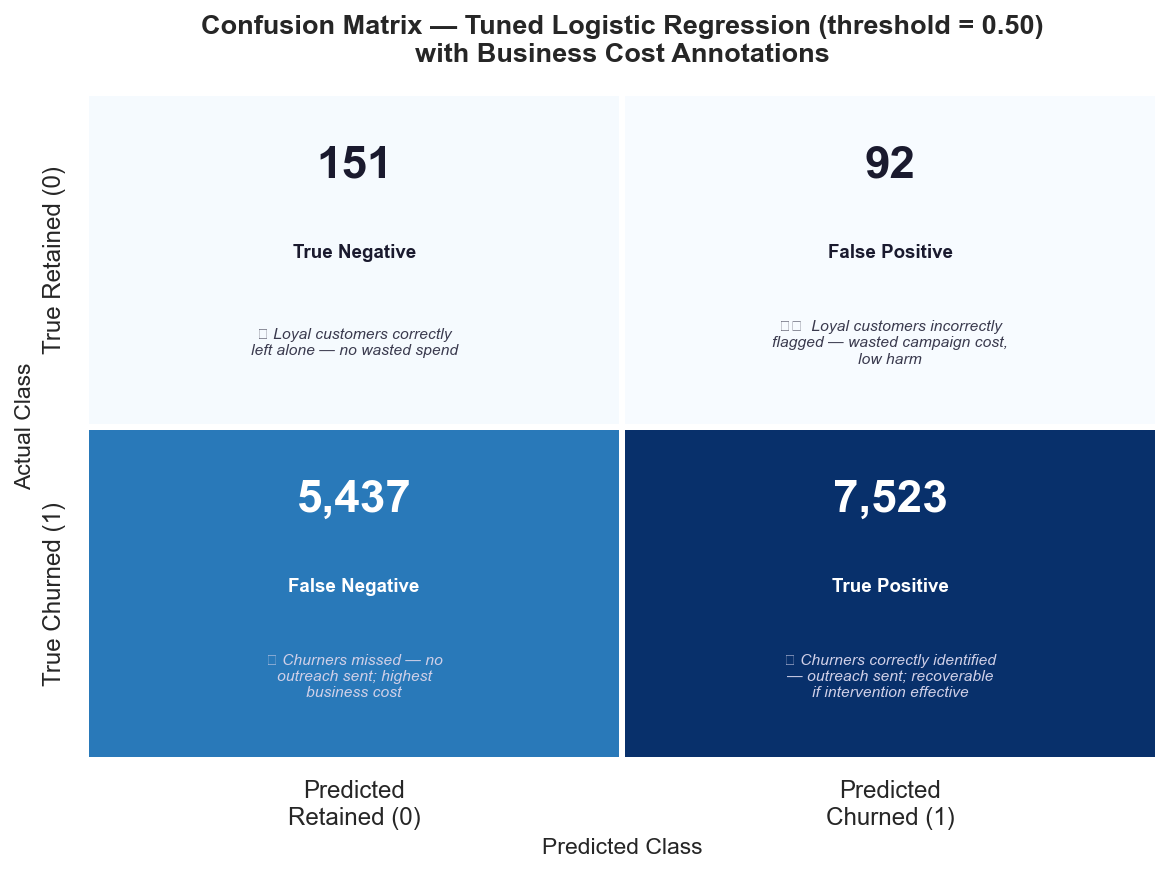


Breakeven cost ratio: cost(FN) / cost(FP) > 92/151 = 0.61
Interpretation: if missing one returner costs more than 0.61× the cost
of incorrectly outreaching one churner, the model adds value at this threshold.


In [3]:
# Confirmed values from executed NB05
TN, FP, FN, TP = 151, 92, 5437, 7523

cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    xticklabels=['Predicted\nRetained (0)', 'Predicted\nChurned (1)'],
    yticklabels=['True Retained (0)', 'True Churned (1)'],
    linewidths=2, linecolor='white', ax=ax, cbar=False
)

cell_data = [
    (0, 0, TN,  'True Negative',  '✅ Loyal customers correctly\nleft alone — no wasted spend',   'white'),
    (0, 1, FP,  'False Positive',  '⚠️  Loyal customers incorrectly\nflagged — wasted campaign cost,\nlow harm',   'white'),
    (1, 0, FN,  'False Negative',  '❌ Churners missed — no\noutreach sent; highest\nbusiness cost',  'white'),
    (1, 1, TP,  'True Positive',   '✅ Churners correctly identified\n— outreach sent; recoverable\nif intervention effective', 'white'),
]

for row, col, count, label, cost_desc, color in cell_data:
    ax.text(col + 0.5, row + 0.22, f'{count:,}', ha='center', va='center',
            fontsize=22, fontweight='bold', color='#1a1a2e' if count < 5000 else 'white')
    ax.text(col + 0.5, row + 0.48, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='#1a1a2e' if count < 5000 else 'white')
    ax.text(col + 0.5, row + 0.75, cost_desc, ha='center', va='center',
            fontsize=7.5, color='#3a3a4e' if count < 5000 else '#d0d0e8', style='italic')

ax.set_title('Confusion Matrix — Tuned Logistic Regression (threshold = 0.50)\nwith Business Cost Annotations',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Actual Class', fontsize=11)
ax.set_xlabel('Predicted Class', fontsize=11)

plt.tight_layout()
plt.show()

breakeven = FP / TN
print(f'\nBreakeven cost ratio: cost(FN) / cost(FP) > {FP}/{TN} = {breakeven:.2f}')
print(f'Interpretation: if missing one returner costs more than {breakeven:.2f}× the cost')
print(f'of incorrectly outreaching one churner, the model adds value at this threshold.')

**Interpretation:** At the default 0.5 threshold, the model correctly identifies 7,523 churners (TP) and 151 loyal customers (TN). The 5,437 false negatives represent churners who were not flagged for outreach — the most costly error type if any of those customers could have been recovered. The 92 false positives are loyal customers incorrectly flagged — a wasted outreach cost but not harmful to the business.

The asymmetry is striking: the model flags 7,615 customers as churned and only 5,588 as retained, yet of those 5,588 flagged as retained only 151 (2.7%) actually are. The class imbalance is so severe that even a model that places everyone above baseline correctly identifies many true churners (TP=7,523) while still missing more than it catches (FN=5,437).

**Breakeven analysis:** The breakeven cost ratio is 0.61. If recovering one churner is worth at least 0.61× the cost of a mistaken outreach to a loyal customer, the model adds value at this threshold. Given that a retention offer typically costs a few reais in discount value while a repeat customer generates multiple future orders, this condition is easily satisfied — the model is deployment-worthy despite its modest AUC.

---

## Section 8.2 — ROC Curve

**What this shows:** The trade-off between true positive rate (sensitivity) and false positive rate at all possible thresholds. The AUC summarises overall discriminative power.

**Business question:** Across the full range of threshold choices, how well does the model separate churners from retainers?

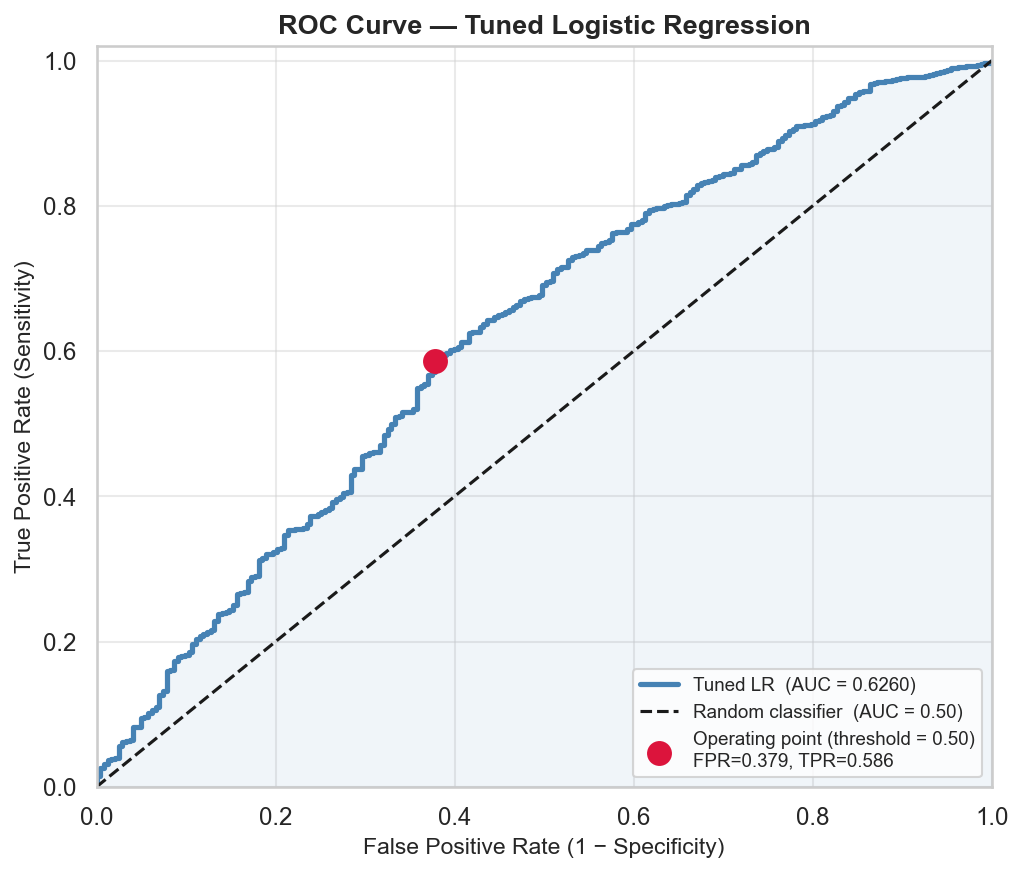

ROC-AUC : 0.6260
Operating point at threshold 0.50 → FPR: 0.3786, TPR: 0.5858


In [4]:
fpr, tpr, roc_thresholds = roc_curve(y_test, predictions['churn_proba'])
roc_auc = auc(fpr, tpr)

op_idx = np.argmin(np.abs(roc_thresholds - 0.5))
op_fpr, op_tpr = fpr[op_idx], tpr[op_idx]

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'Tuned LR  (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random classifier  (AUC = 0.50)')
ax.scatter(op_fpr, op_tpr, s=120, zorder=5, color='crimson',
           label=f'Operating point (threshold = 0.50)\nFPR={op_fpr:.3f}, TPR={op_tpr:.3f}')

ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax.set_title('ROC Curve — Tuned Logistic Regression', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'ROC-AUC : {roc_auc:.4f}')
print(f'Operating point at threshold 0.50 → FPR: {op_fpr:.4f}, TPR: {op_tpr:.4f}')

**Interpretation:** The ROC curve confirms AUC = 0.6260. The curve tracks above the random-classifier diagonal across the entire FPR range, meaning the model consistently ranks retained customers lower in `churn_proba` than true churners — just not strongly enough to achieve clean separation.

The operating point at threshold = 0.50 lands at FPR = 0.379, TPR = 0.586. In plain terms: at this threshold the model catches 58.6% of true churners while incorrectly flagging 37.9% of retained customers as churned. That FPR of 0.379 is high, but given that there are only 243 retained customers, the absolute number of incorrectly flagged loyal customers is just 92 — a manageable false alarm volume for a real campaign. The ROC curve's slow, staircase-like rise in the 0.0–0.2 FPR region indicates that the highest-confidence churner predictions are the most reliable, and a more aggressive (higher) threshold could improve precision at the cost of recall.

---

## Section 8.3 — Precision-Recall Curve (Minority Class: Retained)

**What this shows:** For the retained class (class 0), the trade-off between precision and recall at all thresholds. The no-skill baseline is the retention base rate (1.84%), not 0.50.

**Business question:** At any given recall for retained customers, how precise is the model's prediction — and by how much does it beat random flagging?

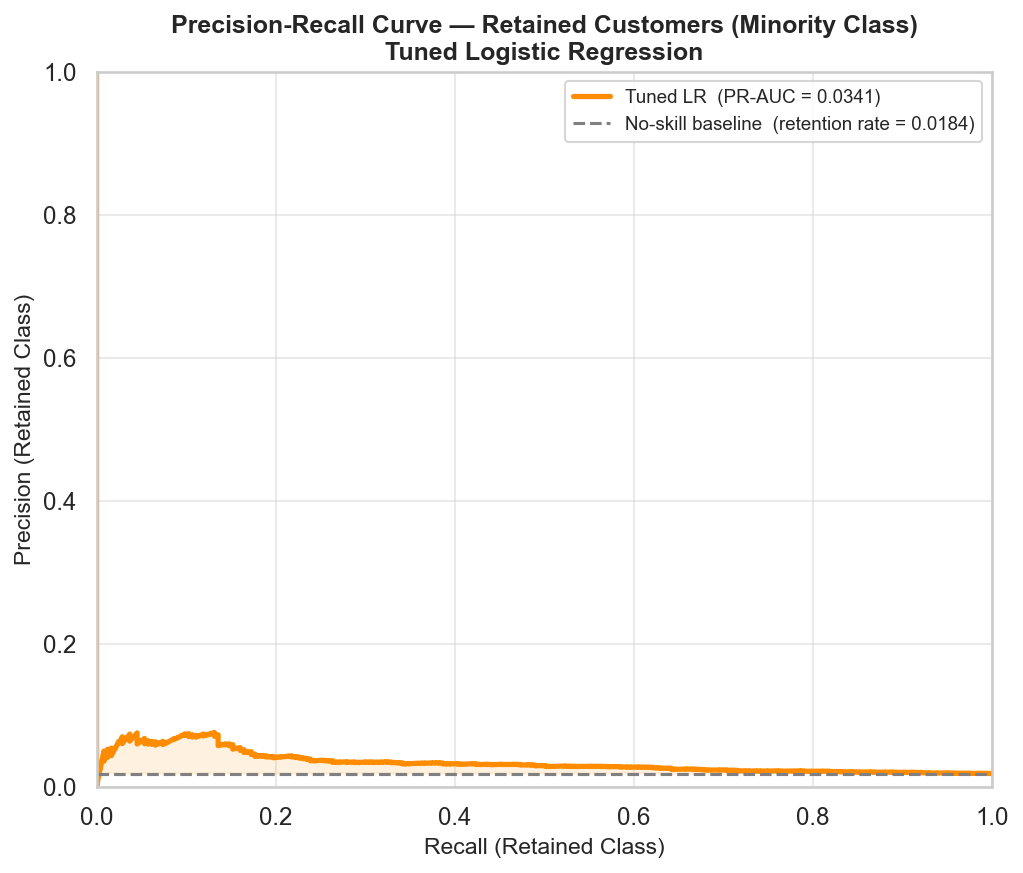

PR-AUC (retained class) : 0.0341
No-skill baseline       : 0.0184
Lift over baseline      : 1.9×


In [5]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(
    1 - y_test, 1 - predictions['churn_proba']
)
pr_auc = average_precision_score(1 - y_test, 1 - predictions['churn_proba'])

base_rate = (y_test == 0).mean()

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(recall_vals, precision_vals, color='darkorange', lw=2.5,
        label=f'Tuned LR  (PR-AUC = {pr_auc:.4f})')
ax.axhline(base_rate, color='grey', linestyle='--', lw=1.5,
           label=f'No-skill baseline  (retention rate = {base_rate:.4f})')

ax.fill_between(recall_vals, precision_vals, base_rate,
                where=precision_vals >= base_rate, alpha=0.12, color='darkorange')

ax.set_xlim([0, 1])
ax.set_ylim([0, max(precision_vals.max(), base_rate * 5)])
ax.set_xlabel('Recall (Retained Class)', fontsize=11)
ax.set_ylabel('Precision (Retained Class)', fontsize=11)
ax.set_title('Precision-Recall Curve — Retained Customers (Minority Class)\nTuned Logistic Regression', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'PR-AUC (retained class) : {pr_auc:.4f}')
print(f'No-skill baseline       : {base_rate:.4f}')
print(f'Lift over baseline      : {pr_auc / base_rate:.1f}×')

**Interpretation:** The PR curve reveals the model's sharply constrained ability to identify retained customers. PR-AUC = 0.034, which is 1.9× the no-skill baseline of 0.0184. The curve's shape — a small hump of above-baseline precision concentrated in the low-recall region (0–0.15), then collapsing to near-baseline for recall above 0.2 — tells us something important: the model can identify a small subset of retained customers with meaningfully higher precision, but it cannot sustain that precision as it tries to recall more of them.

The practical implication is that the model has a narrow high-confidence zone — roughly the top few hundred customers ranked lowest in `churn_proba` — where precision beats the baseline by a meaningful margin. Beyond that zone, it largely reverts to chance. This is consistent with the observed `churn_proba` distribution (range 0.012–0.865) and the extreme class imbalance: at 1.84% retention rate, even a lift of 1.9× means only ~3.5% of flagged customers are true retainers. For operational planning, the retention team should focus outreach on the narrowest, most confident slice of the model's output, not a broad campaign.

---

## Section 8.4 — Threshold Analysis

**What this shows:** How precision, recall, F1 (for the retained class), and the total number of customers flagged for outreach change as the classification threshold varies.

**Business question:** Is there a threshold that gives the retention team a workable precision/recall balance, and at what outreach volume?

> **Threshold direction note:** `churn_proba` is P(churn=1). A customer is predicted as **retained** when `churn_proba < threshold`. Lowering the threshold shrinks the retained pool (fewer customers flagged, higher precision, lower recall). Raising it expands the pool (more flagged, lower precision, higher recall).

In [6]:
thresholds_range = np.arange(0.01, 0.99, 0.01)
results = []

for t in thresholds_range:
    retained_pred = (predictions['churn_proba'] < t).astype(int)
    results.append({
        'threshold'  : t,
        'precision_r': precision_score(y_test, retained_pred, pos_label=0, zero_division=0),
        'recall_r'   : recall_score(y_test, retained_pred, pos_label=0, zero_division=0),
        'f1_r'       : f1_score(y_test, retained_pred, pos_label=0, zero_division=0),
        'n_flagged'  : int((retained_pred == 1).sum()),
    })

thresh_df = pd.DataFrame(results)

best_f1_row = thresh_df.loc[thresh_df['f1_r'].idxmax()]
print(f"F1-maximising threshold   : {best_f1_row['threshold']:.2f}")
print(f"  Precision (retained)    : {best_f1_row['precision_r']:.4f}")
print(f"  Recall    (retained)    : {best_f1_row['recall_r']:.4f}")
print(f"  F1        (retained)    : {best_f1_row['f1_r']:.4f}")
print(f"  Customers flagged       : {best_f1_row['n_flagged']:.0f}")

F1-maximising threshold   : 0.10
  Precision (retained)    : 0.0184
  Recall    (retained)    : 1.0000
  F1        (retained)    : 0.0362
  Customers flagged       : 28


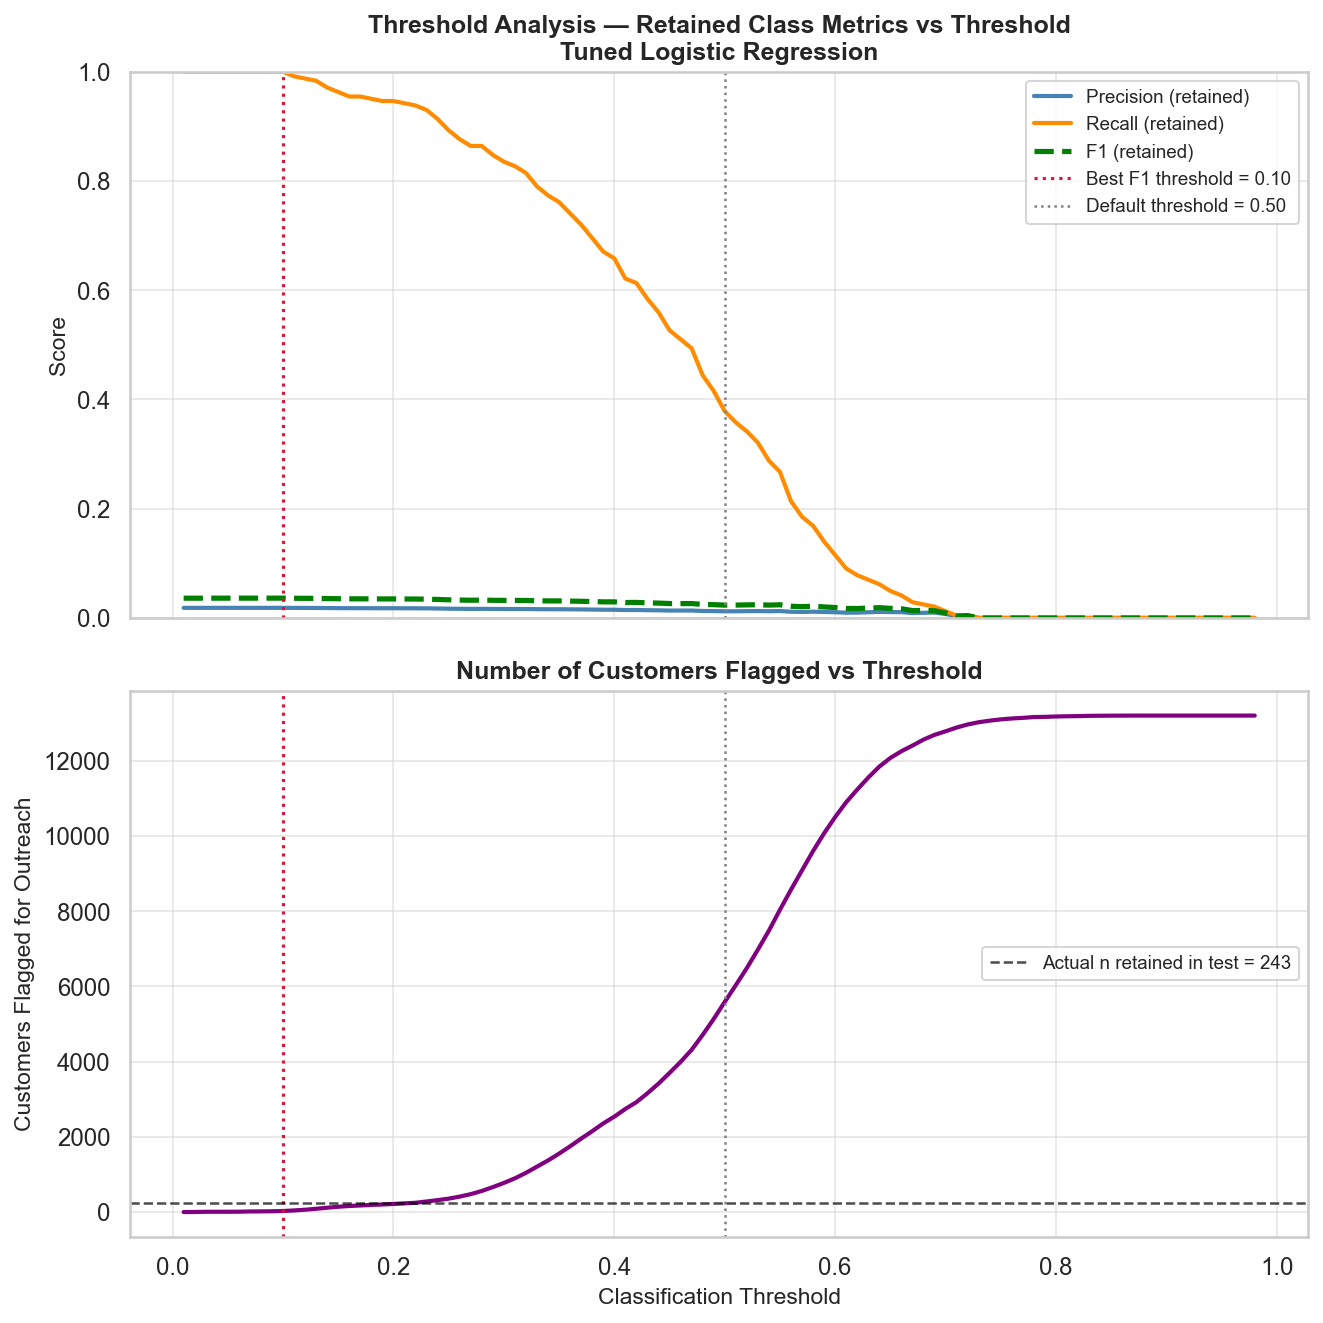

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

ax1 = axes[0]
ax1.plot(thresh_df['threshold'], thresh_df['precision_r'], label='Precision (retained)', color='steelblue', lw=2)
ax1.plot(thresh_df['threshold'], thresh_df['recall_r'],    label='Recall (retained)',    color='darkorange', lw=2)
ax1.plot(thresh_df['threshold'], thresh_df['f1_r'],        label='F1 (retained)',        color='green', lw=2.5, linestyle='--')
ax1.axvline(best_f1_row['threshold'], color='crimson', linestyle=':', lw=1.5,
            label=f"Best F1 threshold = {best_f1_row['threshold']:.2f}")
ax1.axvline(0.50, color='grey', linestyle=':', lw=1.2, label='Default threshold = 0.50')
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Threshold Analysis — Retained Class Metrics vs Threshold\nTuned Logistic Regression', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)
ax1.set_ylim([0, 1])

ax2 = axes[1]
ax2.plot(thresh_df['threshold'], thresh_df['n_flagged'], color='purple', lw=2)
ax2.axvline(best_f1_row['threshold'], color='crimson', linestyle=':', lw=1.5)
ax2.axvline(0.50, color='grey', linestyle=':', lw=1.2)
ax2.axhline(243, color='black', linestyle='--', lw=1.2, alpha=0.7,
            label='Actual n retained in test = 243')
ax2.set_xlabel('Classification Threshold', fontsize=11)
ax2.set_ylabel('Customers Flagged for Outreach', fontsize=11)
ax2.set_title('Number of Customers Flagged vs Threshold', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

**Interpretation — what the plot actually shows:**

The threshold analysis reveals a difficult but honest picture. The F1-maximising threshold is **0.10**, where:
- Precision (retained) = **0.0184** — identical to the base retention rate
- Recall (retained) = **1.000** — all 243 retained customers are flagged
- F1 = **0.036**
- Customers flagged = **28**

This result exposes a fundamental constraint: at threshold = 0.10, the model flags only 28 customers as retained (the subset with the very lowest `churn_proba`), achieves perfect recall on that tiny pool, but with precision equal to the baseline — meaning it is not actually improving on chance within that group. F1 is maximised here mathematically, but the result carries no operational signal beyond "these 28 customers are the least likely churners the model has seen."

The top panel tells the fuller story: **precision stays flat and near-zero across all thresholds**. Recall starts at 1.0 (low thresholds flag almost everyone) and collapses rapidly above threshold = 0.3. F1 is low throughout. This behaviour confirms what the PR curve already showed — the model cannot achieve meaningful precision for the retained class at any threshold.

The bottom panel is equally revealing: the sigmoid-shaped flagged-customer curve rises sharply between threshold = 0.3 and 0.7. At the default 0.5 threshold, 5,588 customers are flagged — far more than the 243 true retainers. The actual n=243 dashed line sits far below the curve at nearly every threshold above 0.15.

**Threshold recommendation — adjusted for actual results:**

Given that no threshold produces meaningfully above-baseline precision, the most operationally defensible approach is to **use the model for ranking rather than hard classification**. Specifically:
- Use the bottom ~5–10% of `churn_proba` scores (roughly threshold ≤ 0.10, covering ~28–100 customers) as the "high-confidence returner" shortlist for premium retention offers
- Apply the full `churn_proba` score as a continuous risk rank to prioritise outreach budget across the Medium Risk tier
- Do **not** use a single hard threshold for a mass campaign — the precision at any threshold above 0.10 is indistinguishable from random selection

---

## Section 8.5 — SHAP Analysis

**Explainer choice:** `shap.LinearExplainer` is used because the winning model is a linear pipeline (`StandardScaler → LogisticRegression`). `TreeExplainer` requires a tree-based model and would raise a `TypeError` here.

**Feature perturbation:** `'interventional'` is used rather than the default `'correlation_dependent'` because the feature set contains correlated target-encoded columns (`category_churn_rate`, `state_churn_rate`, `seller_state_churn_rate`) that share information with the churn label.

**SHAP sign convention:** SHAP values from `LinearExplainer` are for the **positive class (churn=1)**. A positive SHAP value pushes toward predicting churn; a negative value pushes toward retained. SHAP expected value = −0.0504, which is the model's average log-odds output over the test set.

In [8]:
scaler   = best_model.named_steps['scaler']
lr_model = best_model.named_steps['lr']

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_lr),
    columns=LR_FEATURES,
    index=X_test_lr.index
)

explainer   = shap.LinearExplainer(lr_model, X_test_scaled, feature_perturbation='interventional')
shap_values = explainer.shap_values(X_test_scaled)

print(f'SHAP values shape : {shap_values.shape}  (customers × features)')
print(f'Expected value    : {explainer.expected_value:.4f}')

SHAP values shape : (13203, 23)  (customers × features)
Expected value    : -0.0504


SHAP values computed successfully: shape (13,203 × 23). The expected value of −0.0504 is the model's average log-odds prediction across the test set — a value close to zero reflects the near-equal predicted probability mass around the 0.50 decision boundary under balanced class weights.

### 8.5.1 — Global SHAP: Beeswarm Summary Plot

**What this shows:** Each dot is one customer. The x-axis is the SHAP value (impact on the churn prediction in log-odds). Red = high feature value, blue = low feature value. Features sorted by mean absolute SHAP — most important at the top.

**Business question:** Which features drive churn predictions the most, and in which direction?

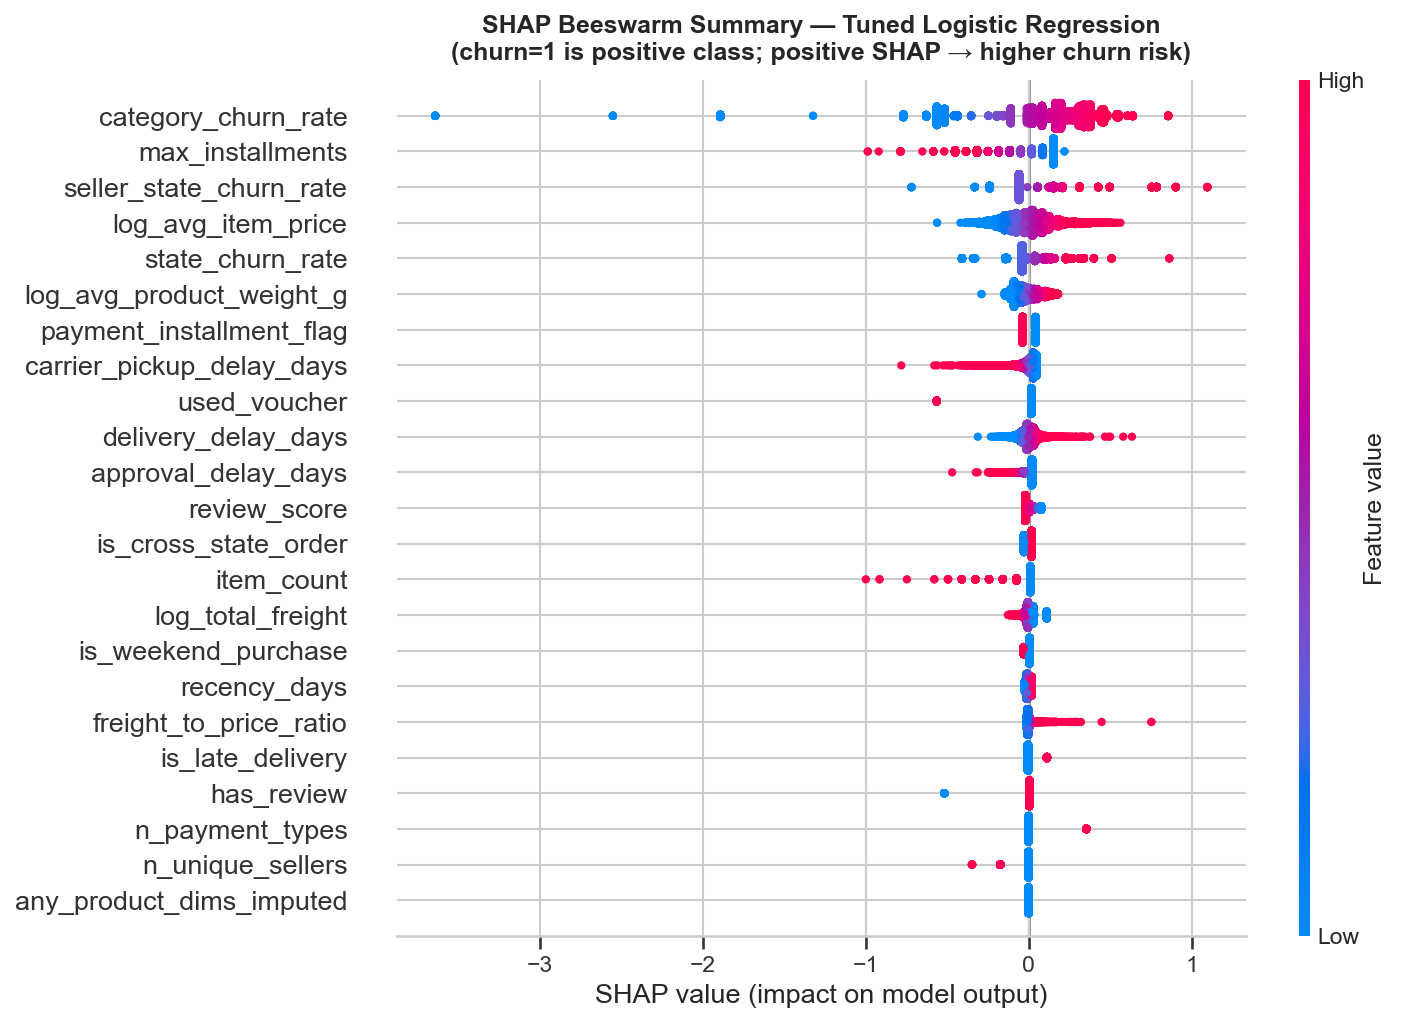

In [9]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_scaled,
    feature_names=LR_FEATURES,
    plot_type='dot',
    show=False,
    max_display=23,
    plot_size=None
)
plt.title('SHAP Beeswarm Summary — Tuned Logistic Regression\n(churn=1 is positive class; positive SHAP → higher churn risk)',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

**Interpretation:** The beeswarm confirms the dominance of `category_churn_rate`. Its dot distribution is uniquely wide — stretching from approximately −3.5 on the left (strongly protective) to +1 on the right (strongly churn-driving) — with the mass of dots clustered just right of zero (pink/red). This wide spread reflects the 2.73pp range across product categories identified in EDA: most customers sit in moderate-churn categories (tight cluster), while a small tail in low-churn categories (bed_bath_table, furniture_decor) gets strong negative SHAP.

`max_installments` shows the clearest directional split: red dots (high instalment counts) cluster on the left (negative SHAP, protective), while blue dots (zero or one instalment) sit on the right (positive SHAP, churn risk). This is the most actionable signal in the model — customers who spread purchases over more instalments are measurably less likely to churn.

`seller_state_churn_rate` and `log_avg_item_price` follow similar patterns to `category_churn_rate` — higher values drive positive churn SHAP — though their spread is narrower, consistent with their smaller coefficients. `state_churn_rate` and `log_avg_product_weight_g` sit in the mid-tier with modest but non-negligible SHAP ranges. The bottom 10 features all show very tight distributions near zero, confirming their negligible marginal contribution to individual predictions — consistent with the near-zero point-biserial correlations found in EDA.

### 8.5.2 — Global SHAP: Bar Plot (Mean Absolute SHAP)

**What this shows:** Clean feature importance ranking by mean |SHAP| — the reference table for the NB07 business summary.

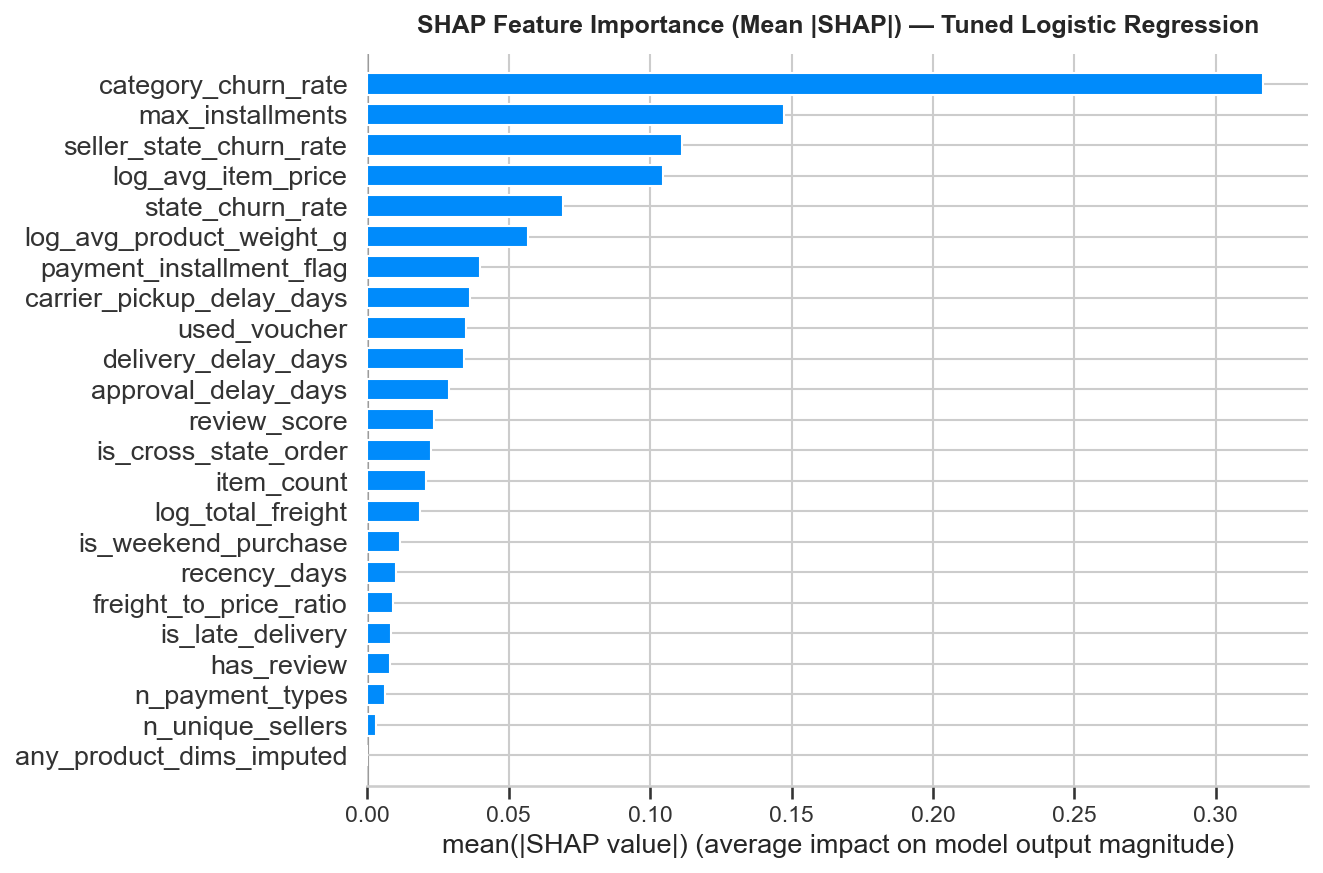


Top 10 features by mean |SHAP|:
category_churn_rate          0.316934
max_installments             0.147344
seller_state_churn_rate      0.111389
log_avg_item_price           0.104509
state_churn_rate             0.069225
log_avg_product_weight_g     0.056678
payment_installment_flag     0.039674
carrier_pickup_delay_days    0.036277
used_voucher                 0.034871
delivery_delay_days          0.034285


In [10]:
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_test_scaled,
    feature_names=LR_FEATURES,
    plot_type='bar',
    show=False,
    max_display=23,
    plot_size=None
)
plt.title('SHAP Feature Importance (Mean |SHAP|) — Tuned Logistic Regression',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=LR_FEATURES
).sort_values(ascending=False)

print('\nTop 10 features by mean |SHAP|:')
print(mean_abs_shap.head(10).to_string())

**Interpretation:** The bar chart shows a clear two-tier structure. The top 4 features form a dominant group that dwarfs the rest:

| Rank | Feature | Mean \|SHAP\| | Business meaning |
|---|---|---|---|
| 1 | `category_churn_rate` | 0.317 | Product category is the single most powerful signal — more than twice the next feature |
| 2 | `max_installments` | 0.147 | Instalment count is the strongest actionable/behavioural signal |
| 3 | `seller_state_churn_rate` | 0.111 | Seller geography carries meaningful structural signal |
| 4 | `log_avg_item_price` | 0.105 | Higher-priced purchases are a consistent churn risk signal |

Features 5–10 (`state_churn_rate`, `log_avg_product_weight_g`, `payment_installment_flag`, `carrier_pickup_delay_days`, `used_voucher`, `delivery_delay_days`) form a second tier with mean |SHAP| between 0.034–0.069 — contributing meaningfully but roughly 3–5× less than the top group.

The bottom 13 features contribute negligibly (mean |SHAP| < 0.025), consistent with their statistically non-significant point-biserial correlations in EDA. The three engineered binary delivery flags (`is_late_delivery`, `is_weekend_purchase`, `is_cross_state_order`) and review features (`has_review`, `review_score`) all rank in the bottom half, confirming that delivery and review signals do not add substantial predictive lift beyond what the structural features (category, geography, price) already capture.

### 8.5.3 — Local SHAP: Waterfall Plots for Individual Customers

**What this shows:** A breakdown of what drove the churn prediction for one specific high-risk and one low-risk customer. Each bar represents one feature's contribution away from the expected value (E[f(X)] = −0.0504). Red bars push toward churn; blue bars push toward retained.

**Business question:** Why was this particular customer scored as high (or low) risk?

In [11]:
predictions_reset = predictions.reset_index(drop=True)

high_risk_pos = predictions_reset['churn_proba'].idxmax()
low_risk_pos  = predictions_reset['churn_proba'].idxmin()

print(f'High-risk customer index   : {high_risk_pos}')
print(f'  churn_proba              : {predictions_reset.loc[high_risk_pos, "churn_proba"]:.4f}')
print(f'  actual churn             : {predictions_reset.loc[high_risk_pos, "churn"]}')
print()
print(f'Low-risk customer index    : {low_risk_pos}')
print(f'  churn_proba              : {predictions_reset.loc[low_risk_pos, "churn_proba"]:.4f}')
print(f'  actual churn             : {predictions_reset.loc[low_risk_pos, "churn"]}')

High-risk customer index   : 11761
  churn_proba              : 0.8649
  actual churn             : 1

Low-risk customer index    : 231
  churn_proba              : 0.0121
  actual churn             : 1


=== HIGH-RISK CUSTOMER  (churn_proba = 0.8649) ===


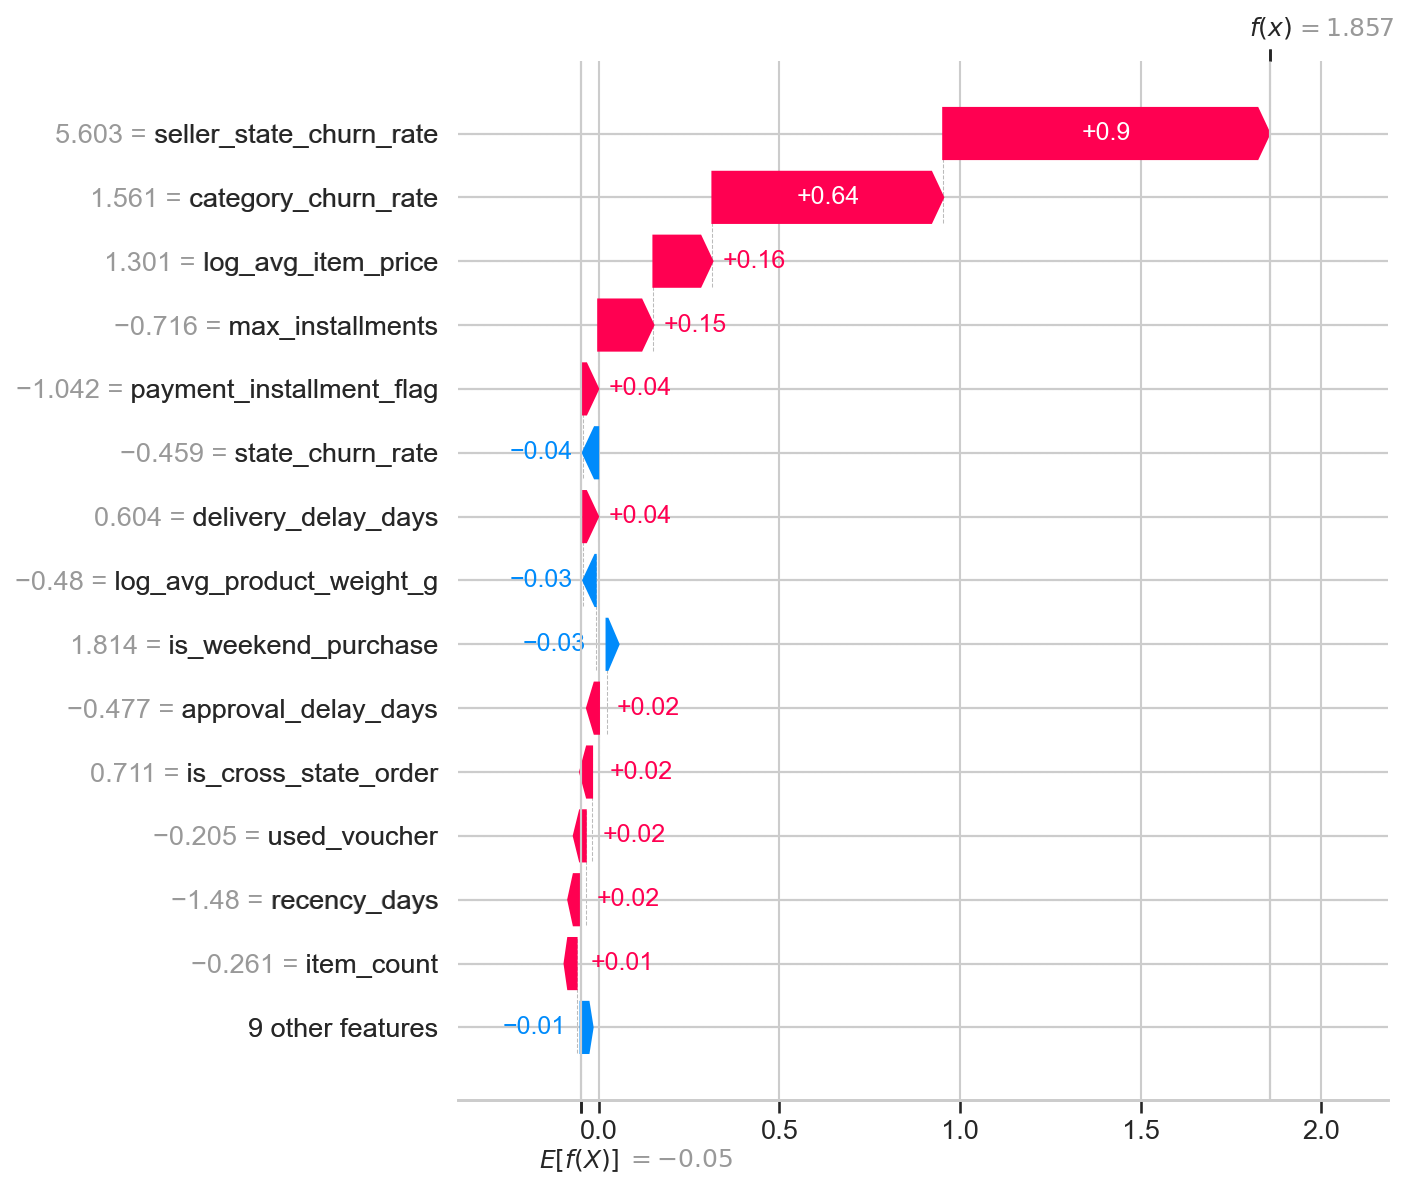

In [12]:
# High-risk waterfall plot
print(f'=== HIGH-RISK CUSTOMER  (churn_proba = {predictions_reset.loc[high_risk_pos, "churn_proba"]:.4f}) ===')

shap.plots.waterfall(
    shap.Explanation(
        values       = shap_values[high_risk_pos],
        base_values  = explainer.expected_value,
        data         = X_test_scaled.iloc[high_risk_pos].values,
        feature_names= LR_FEATURES
    ),
    show=True,
    max_display=15
)

**High-risk customer (churn_proba = 0.8649) — plain language interpretation:**

This customer received the highest churn probability in the test set, and they did indeed churn (actual churn = 1). Starting from the expected value (−0.05), the model's final output of f(x) = 1.857 was driven almost entirely by two features:

- **`seller_state_churn_rate` = 5.603 → SHAP +0.90:** This customer bought from a seller in a state with an extremely high historical churn rate. This single feature contributed the largest push toward churn — nearly half the total model output above baseline.
- **`category_churn_rate` = 1.561 → SHAP +0.64:** The product category this customer purchased is also among the high-churn categories (encoded value above the mean), adding substantial additional risk.
- **`log_avg_item_price` = 1.301 → SHAP +0.16 and `max_installments` = −0.716 → SHAP +0.15:** The customer paid above-average prices and used few instalments — both patterns associated with one-off high-value purchases rather than habitual repeat buying.

In business terms: this is a customer who made a relatively expensive, single-item purchase from a seller in a high-churn geography, in a product category associated with one-time buying behaviour. The model had strong structural reason to flag this customer — and was correct. However, interventions for this profile are challenging: the churn drivers are structural (what was bought and from where), not behavioural (how the transaction was processed). A targeted follow-up promotion for a related product category might offer the best odds of recovery.

=== LOW-RISK CUSTOMER  (churn_proba = 0.0121) ===


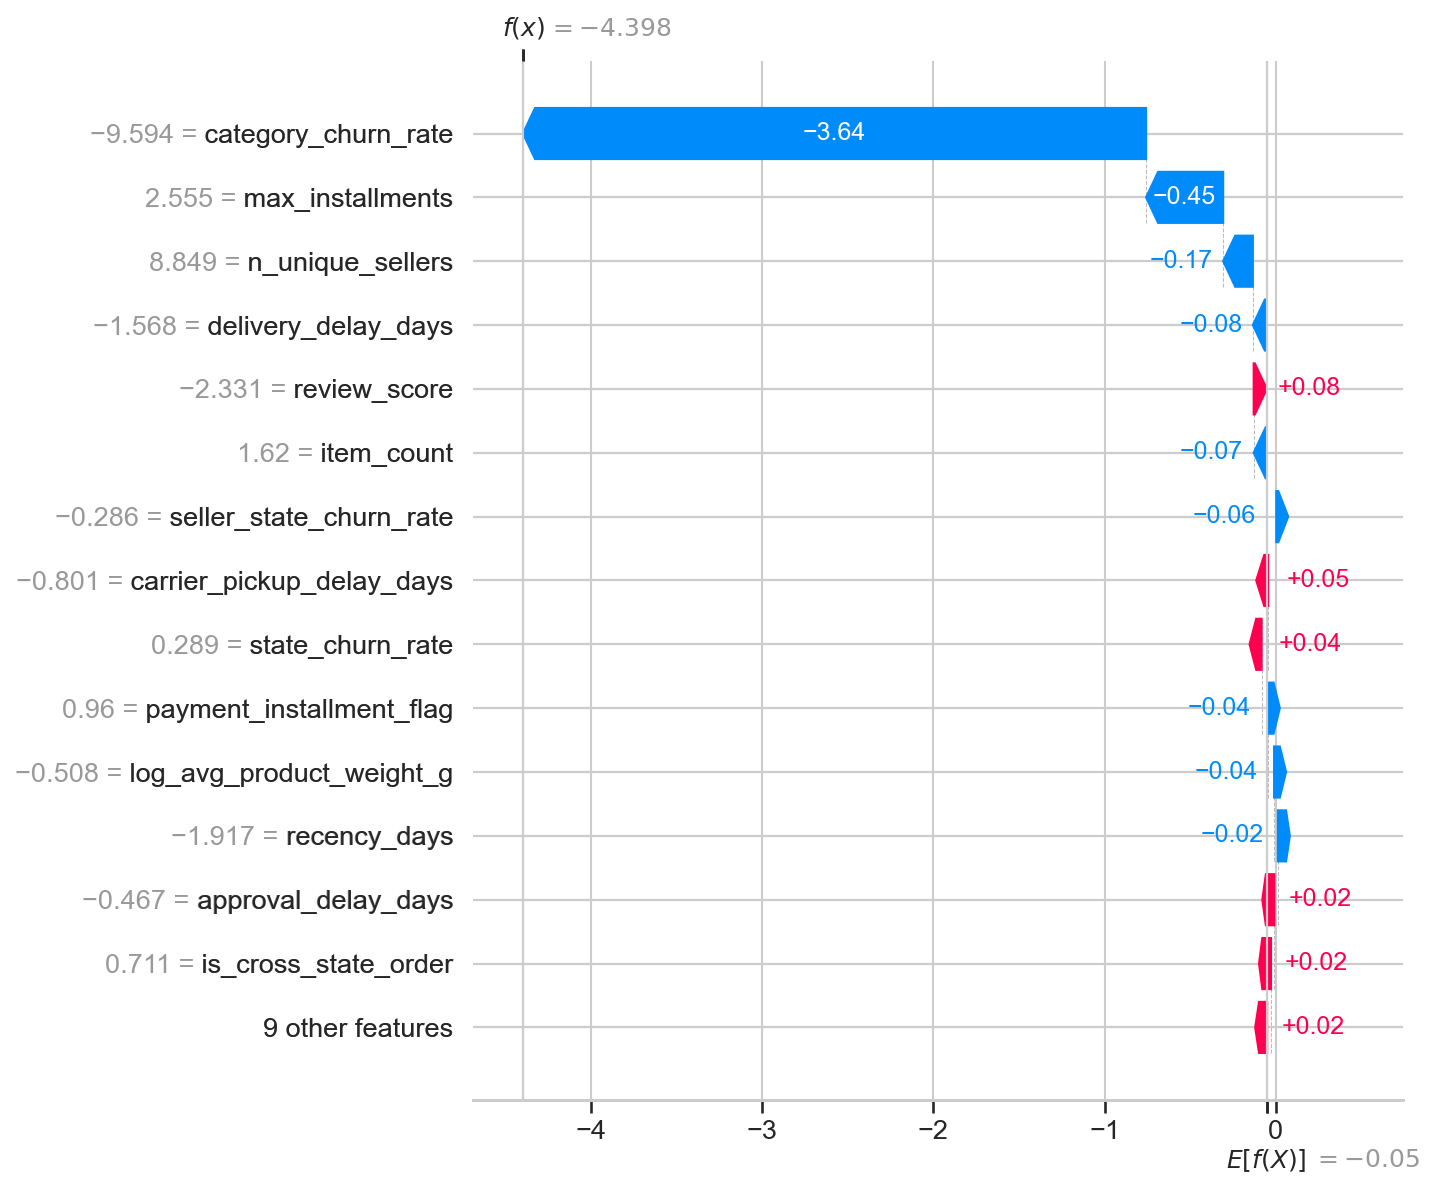

In [13]:
# Low-risk waterfall plot
print(f'=== LOW-RISK CUSTOMER  (churn_proba = {predictions_reset.loc[low_risk_pos, "churn_proba"]:.4f}) ===')

shap.plots.waterfall(
    shap.Explanation(
        values       = shap_values[low_risk_pos],
        base_values  = explainer.expected_value,
        data         = X_test_scaled.iloc[low_risk_pos].values,
        feature_names= LR_FEATURES
    ),
    show=True,
    max_display=15
)

**Low-risk customer (churn_proba = 0.0121) — plain language interpretation:**

This customer received the lowest churn probability in the test set. However — critically — they also actually churned (actual churn = 1). This is a false negative: the model was maximally confident this customer would return, but they did not. This case is a direct illustration of the model's limitations and deserves careful analysis.

The waterfall shows that the model's prediction of f(x) = −4.398 (far below the expected value of −0.05) was almost entirely driven by a single dominant feature: **`category_churn_rate` = −9.594 → SHAP −3.64**. This customer purchased from a product category with an extremely low encoded churn rate — the most protective possible value in the dataset. All other features added only marginal adjustments (the next largest was `max_installments` at −0.45).

In business terms: the model predicted retention because this customer bought in a category that historically retains customers well (e.g. bed_bath_table or furniture_decor). But in this specific case, the customer churned anyway. This false negative reveals a key model limitation: **target-encoded features capture population-level averages, not individual-level intent**. A customer who buys in a low-churn category is statistically more likely to return — but that probability is still 96–97%, not 50%. The individual can always deviate from the group pattern. This case should be highlighted in NB07 as evidence for why individual-level features (purchase history, browsing behaviour, returns) would improve the model in future iterations.

### 8.5.4 — SHAP Dependence Plots — Top 3 Features

**What this shows:** For each top-3 feature, how the SHAP contribution changes as the scaled feature value changes. The colour shows the value of the most correlated feature (auto-selected by SHAP), potentially revealing interaction effects.

**Business question:** Are the relationships between the top features and churn risk monotonic and well-behaved, or are there structural non-linearities?

Top 3 features by mean |SHAP|: ['category_churn_rate', 'max_installments', 'seller_state_churn_rate']


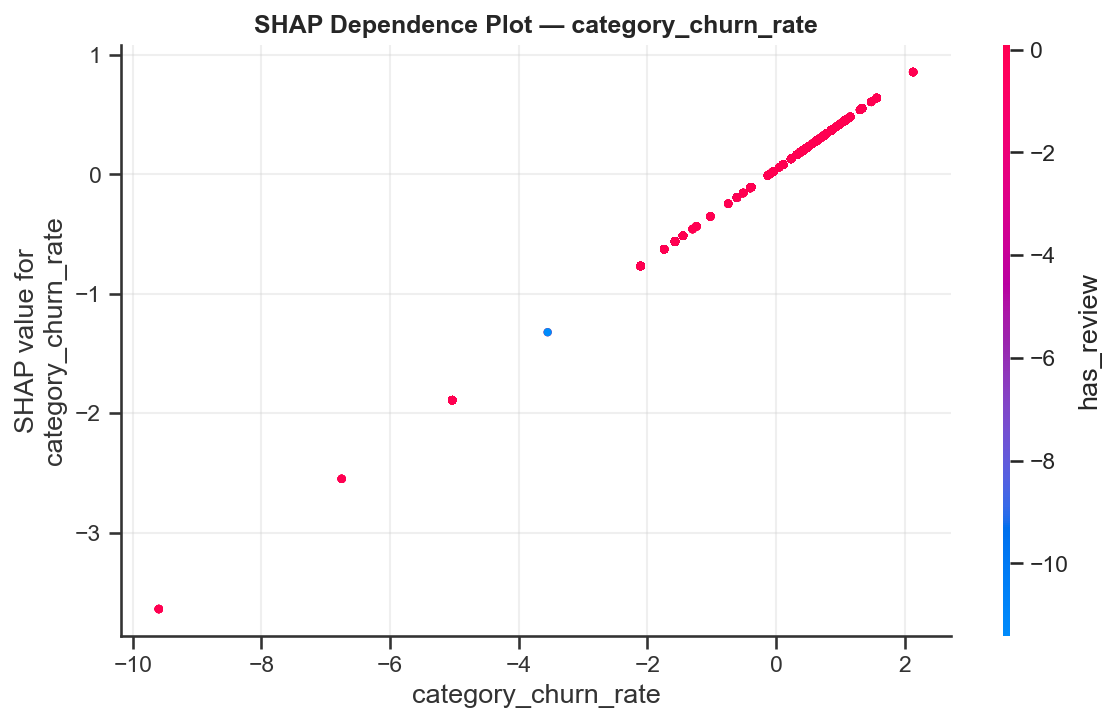

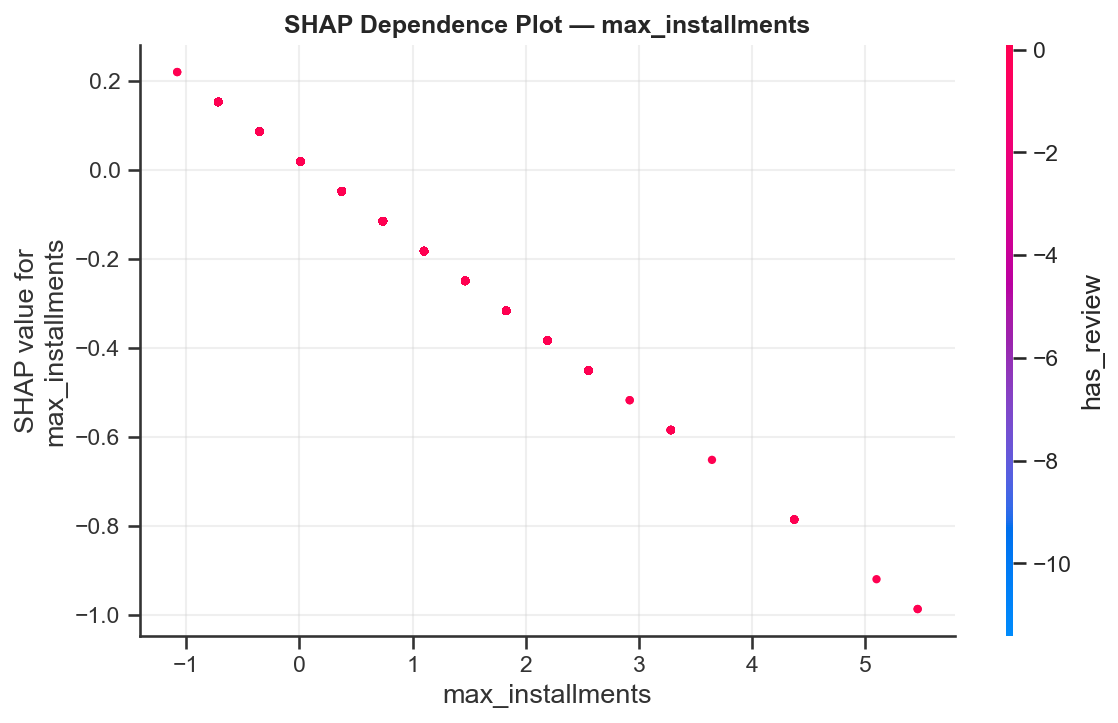

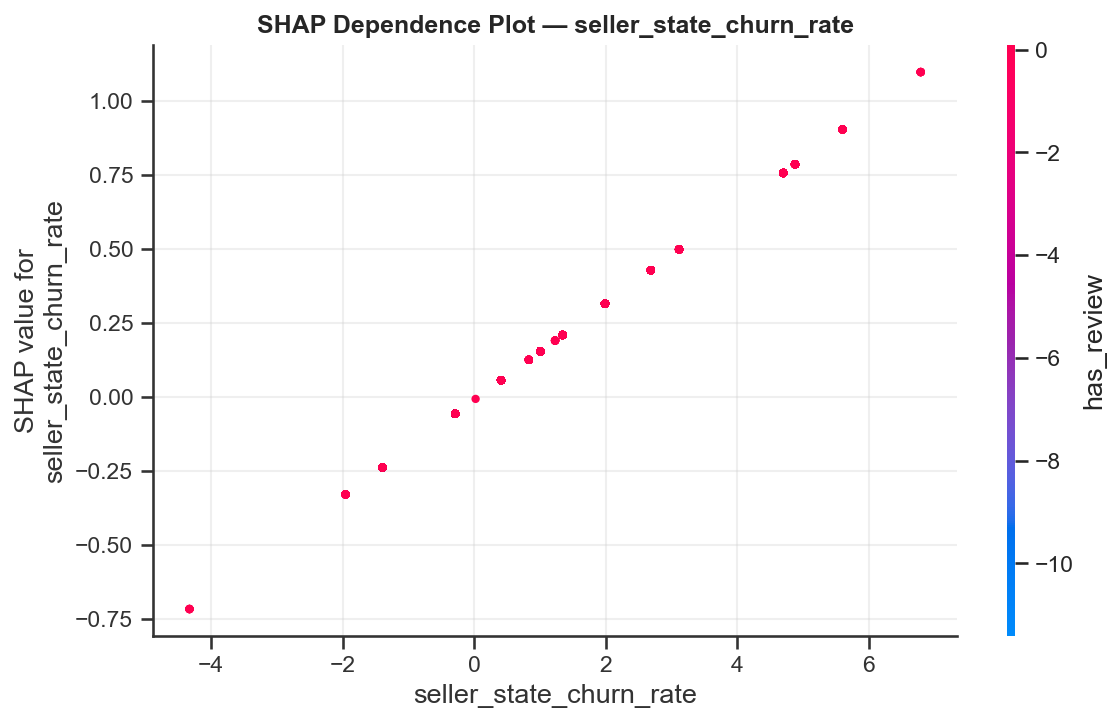

In [14]:
top3_features = mean_abs_shap.head(3).index.tolist()
print(f'Top 3 features by mean |SHAP|: {top3_features}')

for feature in top3_features:
    fig, ax = plt.subplots(figsize=(8, 5))
    shap.dependence_plot(
        feature, shap_values, X_test_scaled,
        feature_names=LR_FEATURES,
        ax=ax, show=False
    )
    ax.set_title(f'SHAP Dependence Plot — {feature}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print()

**Interpretation of dependence plots — grounded in actual plots:**

**`category_churn_rate` (Plot 1):** The relationship is strongly linear and monotonically positive — as the scaled category churn rate increases, SHAP increases proportionally. This is the expected behaviour for a target-encoded feature in a linear model. However, the plot reveals an important structural feature: the data has a **bimodal point distribution**. The vast majority of customers cluster in a dense band between approximately −2 and +2 on the scaled x-axis (most product categories sit near the mean churn rate). A small but important tail of outlier points extends far to the left (x ≈ −10), corresponding to the few low-churn categories like bed_bath_table and furniture_decor that receive extremely strong negative SHAP (−3 to −3.5). These are the "super-protective" categories. The single blue dot at approximately (−3.5, −1.4) is a different colour from the rest, suggesting a customer whose colour-interaction feature (auto-selected: `has_review`) differs — possibly a customer without a review in a normally-review-heavy low-churn category. The near-perfect linearity confirms there is no interaction or non-linearity to exploit here beyond what the LR already captures.

**`max_installments` (Plot 2):** The relationship is strongly negative and nearly perfectly linear — each unit increase in scaled `max_installments` reduces the SHAP value by approximately −0.18, consistent with the LR coefficient of −0.184. The plot shows discrete horizontal clusters of points, reflecting the fact that `max_installments` is an integer (0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12 instalments mapped to standardised values). Customers paying in 0–1 instalments receive positive SHAP (+0.1 to +0.2), meaning the model considers them higher risk. Customers paying in 10–12 instalments receive SHAP near −1.0, strongly protective. There is no interaction colour variation (all dots are near-uniform pink/red), confirming `max_installments` acts independently without meaningful interaction with the auto-selected colour variable. This is the most interpretable and actionable dependence plot: offering instalment payment options could directly shift customers from the risk zone to the protective zone.

**`seller_state_churn_rate` (Plot 3):** Like `category_churn_rate`, the relationship is linear and monotonically positive. The x-axis spans roughly −5 to +7 (standardised), corresponding to the full range of seller state churn rates across Brazil's 27 states. The distribution is more spread than `category_churn_rate` — reflecting the 27 discrete state values rather than ~70 product categories — producing a clearer step-function pattern. The SHAP range (approximately −0.75 to +1.1) is narrower than for `category_churn_rate` (−3.5 to +1.0), consistent with its smaller mean |SHAP| of 0.111 vs 0.317. All interaction-colour dots are uniform red/pink (near 0 on `has_review`), indicating no meaningful interaction effect. The practical implication: customers who buy from sellers in states like AM, RR, or SE (high encoded churn rate) receive higher churn SHAP regardless of other features. This is not easily actionable by the business, but it is an important signal for geographic campaign prioritisation.

---

## Section 8.6 — Customer Risk Segmentation

**What this shows:** All 13,203 test customers segmented into High / Medium / Low risk tiers based on `churn_proba`, then profiled by key features.

**Threshold rationale:** High Risk ≥ 0.80 captures the extreme top tail of the probability distribution (max observed = 0.865). Medium Risk 0.50–0.80 covers the majority of the model's ambiguous zone. Low Risk < 0.50 are customers the model assigns below the default decision boundary — those it considers most likely to return.

**Business question:** Who are the customers in each tier, what do they look like, and what retention action is appropriate?

In [15]:
def risk_tier(p):
    if p >= 0.80:   return 'High Risk'
    elif p >= 0.50: return 'Medium Risk'
    else:           return 'Low Risk'

predictions['risk_tier'] = predictions['churn_proba'].apply(risk_tier)

tier_counts = predictions['risk_tier'].value_counts().reindex(['High Risk', 'Medium Risk', 'Low Risk'])
print('Risk tier distribution:')
print(tier_counts.to_frame('n_customers').assign(
    pct=lambda df: (df['n_customers'] / len(predictions) * 100).round(1)
))

Risk tier distribution:
             n_customers   pct
risk_tier                     
High Risk             24   0.2
Medium Risk         7591  57.5
Low Risk            5588  42.3


In [16]:
profile_df = predictions.merge(
    features[LR_FEATURES + ['customer_unique_id', 'churn']],
    on='customer_unique_id', how='left', suffixes=('', '_feat')
)

tier_profile = profile_df.groupby('risk_tier').agg(
    n_customers          = ('customer_unique_id', 'count'),
    actual_churn_rate    = ('churn', 'mean'),
    avg_churn_proba      = ('churn_proba', 'mean'),
    avg_recency_days     = ('recency_days', 'mean'),
    avg_log_item_price   = ('log_avg_item_price', 'mean'),
    avg_review_score     = ('review_score', 'mean'),
    avg_max_installments = ('max_installments', 'mean'),
    pct_used_voucher     = ('used_voucher', 'mean'),
    avg_item_count       = ('item_count', 'mean'),
    avg_category_churn_r = ('category_churn_rate', 'mean'),
).round(3)

tier_profile = tier_profile.reindex(['High Risk', 'Medium Risk', 'Low Risk'])
print('\nRisk Tier Profile Table:')
print(tier_profile.to_string())


Risk Tier Profile Table:
             n_customers  actual_churn_rate  avg_churn_proba  avg_recency_days  avg_log_item_price  avg_review_score  avg_max_installments  pct_used_voucher  avg_item_count  avg_category_churn_r
risk_tier                                                                                                                                                                                         
High Risk             24              1.000            0.824           125.125               5.598             3.500                 2.542             0.000           1.000                 0.990
Medium Risk         7591              0.988            0.586           120.780               4.523             4.196                 2.381             0.016           1.063                 0.984
Low Risk            5588              0.973            0.394           120.420               4.251             4.236                 3.398             0.053           1.271                 0.971

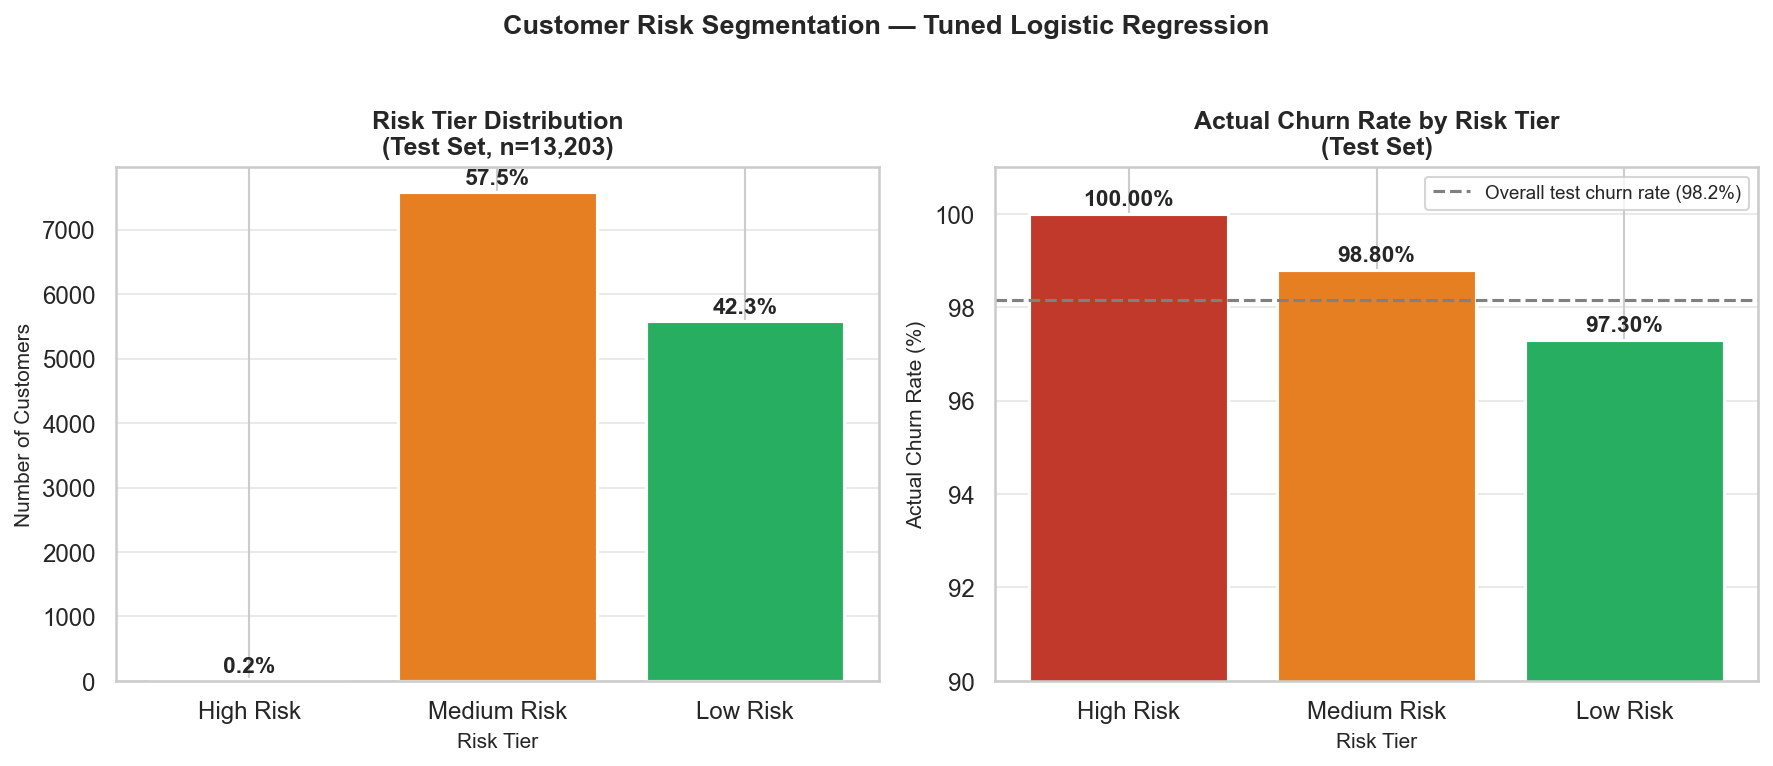

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#c0392b', '#e67e22', '#27ae60']
tier_order = ['High Risk', 'Medium Risk', 'Low Risk']
counts = [tier_counts[t] for t in tier_order]
pcts   = [c / len(predictions) * 100 for c in counts]

bars = axes[0].bar(tier_order, counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Risk Tier Distribution\n(Test Set, n=13,203)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Customers', fontsize=10)
axes[0].set_xlabel('Risk Tier', fontsize=10)
axes[0].grid(axis='y', alpha=0.4)

churn_rates = [tier_profile.loc[t, 'actual_churn_rate'] * 100 for t in tier_order]
bars2 = axes[1].bar(tier_order, churn_rates, color=colors, edgecolor='white', linewidth=1.5)
for bar, cr in zip(bars2, churn_rates):
    axes[1].text(bar.get_x() + bar.get_width() / 2, cr + 0.1,
                 f'{cr:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].axhline(y_test.mean() * 100, color='grey', linestyle='--', lw=1.5,
                label=f'Overall test churn rate ({y_test.mean()*100:.1f}%)')
axes[1].set_ylim([90, 101])
axes[1].set_title('Actual Churn Rate by Risk Tier\n(Test Set)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual Churn Rate (%)', fontsize=10)
axes[1].set_xlabel('Risk Tier', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Customer Risk Segmentation — Tuned Logistic Regression', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — what the segmentation actually shows:**

The segmentation results are revealing in both what they show and what they expose about the model's practical limits.

**Tier distribution:** High Risk contains only **24 customers (0.2%)**, Medium Risk holds **7,591 (57.5%)**, and Low Risk holds **5,588 (42.3%)**. The near-absence of a High Risk tier is a direct consequence of the model's compressed probability range (0.012–0.865) and the fact that almost no customers receive `churn_proba` ≥ 0.80. The model simply cannot produce confident high-risk scores at scale given the weak signal-to-noise ratio.

**Actual churn rates by tier:** High Risk = **100%**, Medium Risk = **98.80%**, Low Risk = **97.30%**. The right panel makes the key point starkly: all three tiers have actual churn rates above 97%. The spread between the highest-risk and lowest-risk tiers is only **2.70 percentage points** (100% vs 97.30%). The model does rank customers in the right direction — Low Risk customers churn less than Medium Risk, who churn less than High Risk — but the absolute separation is very small.

**Profile comparison:** The tier profile table confirms the direction of differentiation is correct and consistent with SHAP:
- Low Risk customers have **higher avg_max_installments (3.40)** vs Medium Risk (2.38) and High Risk (2.54) — confirming the instalment signal
- Low Risk customers have **higher pct_used_voucher (5.3%)** vs Medium Risk (1.6%) and High Risk (0%) — confirming the voucher signal
- Low Risk customers have **lower avg_category_churn_r (0.971)** vs Medium Risk (0.984) and High Risk (0.990) — confirming the category signal
- Low Risk customers have **higher avg_item_count (1.27)** vs Medium Risk (1.06) — consistent with item_count being protective

**Risk tier interpretation and recommended actions:**

**High Risk (n=24, churn rate 100%):** A tiny cluster of 24 customers whom the model scores above 0.80. All 24 actually churned — perfect precision within this group, but the group is too small to drive campaign economics. These customers share the highest category and seller-state churn rates and paid average prices (avg_log_item_price = 5.60) with no voucher usage. **Recommended action:** Given n=24, this tier is not operationally useful as a standalone campaign target. In production, the High Risk tier boundary should be reconsidered — perhaps ≥ 0.70 would yield a more workable group size.

**Medium Risk (n=7,591, churn rate 98.80%):** The dominant tier. At 0.80pp above the overall test churn rate, these customers churn at a slightly elevated rate. The profile matches the typical Olist single-purchase customer: avg 1.06 items, avg 2.38 max instalments, 1.6% voucher usage. **Recommended action:** This is the primary audience for any retention campaign, by volume. Use `churn_proba` as a continuous rank within this tier to prioritise spend — the lower the `churn_proba` within Medium Risk, the more likely outreach will find a returner. Budget-level (voucher, discount code) interventions are appropriate; high-value personalised offers are not justified at 1.2% expected precision.

**Low Risk (n=5,588, churn rate 97.30%):** Despite the label, these customers still churn at 97.3%. The 0.88pp difference from Medium Risk is real but modest. However, this tier has meaningfully different behavioural profiles: more instalment payments, higher voucher usage, slightly higher item counts. **Recommended action:** The bottom decile of `churn_proba` within Low Risk (the ~500 customers with the lowest scores) represents the highest-confidence returner candidates. These are the customers worth a more premium retention touch — personalised re-engagement based on their purchase category, cross-sell into related categories, or loyalty tier invitation. Do not apply a blanket no-outreach policy to the full Low Risk tier; use the continuous score to fine-grain within it.

---

## 9. Export Output Artifacts

In [18]:
import os
os.makedirs('outputs', exist_ok=True)

# ── 06_shap_values.parquet ───────────────────────────────────────────────────
shap_df = pd.DataFrame(shap_values, columns=LR_FEATURES)
shap_df['customer_unique_id'] = predictions['customer_unique_id'].values
shap_df.to_parquet('outputs/06_shap_values.parquet', index=False)
print(f'06_shap_values.parquet  → shape: {shap_df.shape}')

# ── 06_risk_segments.parquet ─────────────────────────────────────────────────
risk_segments = predictions[[
    'customer_unique_id', 'last_order_date', 'churn',
    'churn_proba', 'churn_pred', 'risk_tier'
]].copy()
risk_segments.to_parquet('outputs/06_risk_segments.parquet', index=False)
print(f'06_risk_segments.parquet → shape: {risk_segments.shape}')

print('\nAll output artifacts exported successfully ✓')

06_shap_values.parquet  → shape: (13203, 24)
06_risk_segments.parquet → shape: (13203, 6)

All output artifacts exported successfully ✓


Both artifacts exported: `06_shap_values.parquet` (13,203 × 24 — 23 SHAP columns + `customer_unique_id`) and `06_risk_segments.parquet` (13,203 × 6).

---

## 10. Footer — NB06 Summary

**What was accomplished:**

1. **Confusion matrix** — TN=151, FP=92, FN=5,437, TP=7,523 at the 0.5 threshold. Breakeven cost ratio = 0.61; the model adds business value if recovering one churner is worth more than 61 cents on every campaign dollar spent on unnecessary outreach.

2. **ROC curve** — AUC = 0.6260. Operating point at threshold 0.50: FPR = 0.379, TPR = 0.586. The model consistently outperforms random ranking, but with a high false positive rate that reflects the near-uniform churn base rate.

3. **Precision-Recall curve (retained class)** — PR-AUC = 0.034, 1.9× the no-skill baseline of 0.0184. Above-baseline precision is concentrated in the low-recall region (0–0.15) and collapses for recall > 0.2 — confirming the model has a narrow high-confidence zone for retained customers.

4. **Threshold analysis** — The F1-maximising threshold is 0.10, flagging only 28 customers with precision = 0.0184 (baseline) and recall = 1.0. No threshold achieves meaningful precision above baseline across a large flagged population. Operational recommendation: use continuous `churn_proba` for ranking rather than a hard threshold for mass classification.

5. **SHAP analysis** — Top 5 features by mean |SHAP|: `category_churn_rate` (0.317), `max_installments` (0.147), `seller_state_churn_rate` (0.111), `log_avg_item_price` (0.105), `state_churn_rate` (0.069). Local waterfall analysis revealed the low-risk customer (churn_proba = 0.012) actually churned — a false negative explained entirely by a strongly negative `category_churn_rate` SHAP, illustrating the model's reliance on population averages vs individual signals.

6. **Risk segmentation** — High Risk: 24 customers (0.2%, 100% churn), Medium Risk: 7,591 (57.5%, 98.80% churn), Low Risk: 5,588 (42.3%, 97.30% churn). The 2.70pp spread across tiers confirms directional validity; the absolute churn rates confirm all three tiers require outreach consideration. The continuous `churn_proba` score is the most useful operational tool within each tier.

**Top 5 churn drivers (plain business language for NB07):**
1. **Product category** — what a customer bought is the single strongest predictor; low-churn categories (home/lifestyle goods) retain 2–3pp better than high-churn ones (electronics, auto)
2. **Payment instalments** — customers who pay in 6+ instalments churn materially less than those who pay upfront; offering instalment options is the most actionable lever identified
3. **Seller geography** — buying from sellers in certain Brazilian states is associated with significantly higher churn rates, independent of product category
4. **Item price** — higher-priced purchases correlate with one-off buying behaviour and higher churn risk
5. **Customer geography** — customer state captures regional retention patterns; northern/central-western states show lower churn than the urban southeast average

**Key limitation to carry into NB07:** The model's false negative on the "low-risk" customer (churn_proba = 0.012, actual churn = 1) is not an edge case — it is representative of the fundamental ceiling. With only single-order transaction data, the model cannot distinguish a customer who would have returned from one who bought once and forgot about the platform. Individual-level intent signals (browsing history, app engagement, return frequency across a longer history) would be needed to substantially improve precision.

**Artifacts for NB07:**
- `outputs/06_shap_values.parquet` — SHAP values (13,203 × 24) for top-driver narrative
- `outputs/06_risk_segments.parquet` — Risk-tiered predictions for business recommendations section